# Level 1 — Task 4: Sentiment Analysis

**Objective:** Classify review text as positive, negative, or neutral and compare two models.

**Tech stack:** Python, pandas, scikit-learn, NLTK-style preprocessing, matplotlib/seaborn

TF-IDF (Term Frequency–Inverse Document Frequency) turns text into numbers: it up-weights words that appear often in a review but are rare across the whole corpus, so generic words like “the” matter less than opinion words like “terrible” or “excellent”.

## 1. Load data and class distribution

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")
DATA = Path("..") / "data" / "raw" / "customer_reviews.csv"
df = pd.read_csv(DATA)
print(df.shape)
print(df["sentiment"].value_counts())
df.head()


(660, 2)
sentiment
neutral     220
positive    220
negative    220
Name: count, dtype: int64


,review_text,sentiment
0,Neither impressed nor disappointed overall.,neutral
1,Neither impressed nor disappointed overall. Ju...,neutral
2,"Amazing app, very easy to use and super fast. ...",positive
3,"The product is okay, nothing special but it wo...",neutral
4,"Absolutely loved this product, excellent quali...",positive


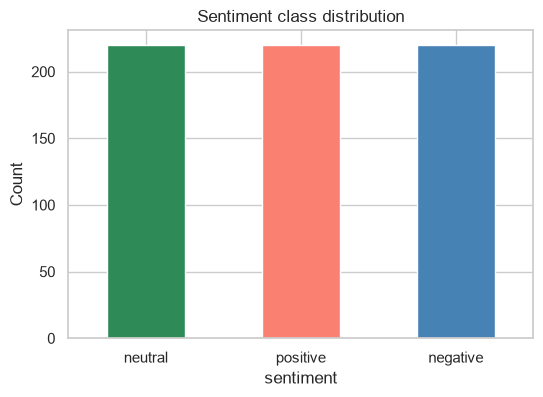

In [2]:
plt.figure(figsize=(6, 4))
df["sentiment"].value_counts().plot(kind="bar", color=["seagreen", "salmon", "steelblue"])
plt.title("Sentiment class distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


## 2. Text preprocessing pipeline

In [3]:
STOP = set(
    "a an the and or but if in on at to for of is are was were be been being this that it with from by as not no yes so very just".split()
)

def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [t for t in text.split() if t not in STOP and len(t) > 2]
    # light suffix stemming
    stemmed = []
    for t in tokens:
        for suf in ("ing", "ed", "ly", "es", "s"):
            if t.endswith(suf) and len(t) > len(suf) + 2:
                t = t[: -len(suf)]
                break
        stemmed.append(t)
    return " ".join(stemmed)

df["clean_text"] = df["review_text"].map(preprocess)
df[["review_text", "clean_text", "sentiment"]].head()


,review_text,clean_text,sentiment
0,Neither impressed nor disappointed overall.,neither impress nor disappoint overall,neutral
1,Neither impressed nor disappointed overall. Ju...,neither impress nor disappoint overall shar re...,neutral
2,"Amazing app, very easy to use and super fast. ...",amaz app easy use super fast shar review,positive
3,"The product is okay, nothing special but it wo...",product okay noth special work,neutral
4,"Absolutely loved this product, excellent quali...",absolute lov product excellent quality fast de...,positive


**Pipeline:** lowercase → strip URLs/punctuation → tokenize → drop stopwords → light stemming. This reduces noise before vectorization.

## 3. TF-IDF feature extraction

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["sentiment"], test_size=0.2, random_state=42, stratify=df["sentiment"]
)
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
Xtr = vectorizer.fit_transform(X_train)
Xte = vectorizer.transform(X_test)
print("Train/test:", Xtr.shape, Xte.shape)
print("Example features:", list(vectorizer.get_feature_names_out()[:15]))


Train/test: (528, 377) (132, 377)
Example features: ['about', 'about some', 'absolute', 'absolute lov', 'acceptable', 'acceptable wait', 'advertis', 'advertis bought', 'advertis please', 'advertis shar', 'advertis thank', 'after', 'after two', 'again', 'again bought']


## 4–6. Train two classifiers and evaluate

Multinomial Naive Bayes
Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        44
     neutral       1.00      1.00      1.00        44
    positive       1.00      1.00      1.00        44

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



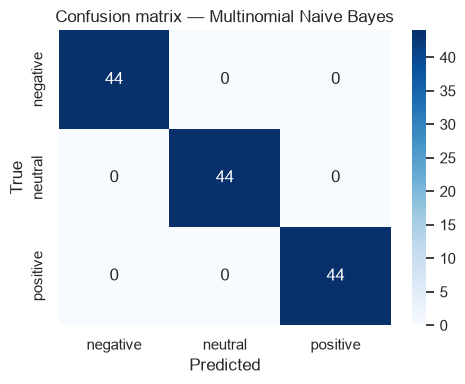

Logistic Regression
Accuracy=1.000  Precision=1.000  Recall=1.000  F1=1.000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        44
     neutral       1.00      1.00      1.00        44
    positive       1.00      1.00      1.00        44

    accuracy                           1.00       132
   macro avg       1.00      1.00      1.00       132
weighted avg       1.00      1.00      1.00       132



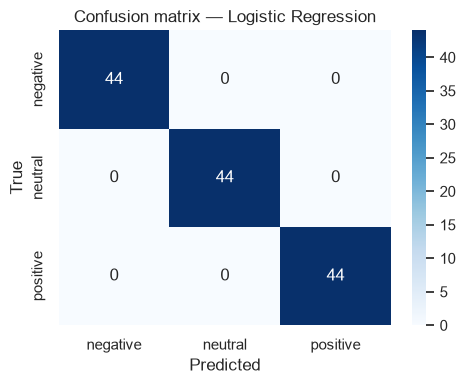

,model,accuracy,precision,recall,f1
0,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
1,Logistic Regression,1.0,1.0,1.0,1.0


In [5]:
def evaluate(name, model):
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="weighted", zero_division=0)
    print("=" * 60)
    print(name)
    print(f"Accuracy={acc:.3f}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}")
    print(classification_report(y_test, pred))
    cm = confusion_matrix(y_test, pred, labels=["negative", "neutral", "positive"])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["negative", "neutral", "positive"],
                yticklabels=["negative", "neutral", "positive"])
    plt.title(f"Confusion matrix — {name}")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()
    return model, pred, {"model": name, "accuracy": acc, "precision": p, "recall": r, "f1": f1}

nb, nb_pred, nb_m = evaluate("Multinomial Naive Bayes", MultinomialNB())
lr, lr_pred, lr_m = evaluate("Logistic Regression", LogisticRegression(max_iter=1000))
pd.DataFrame([nb_m, lr_m])


## 7. Word frequency by class (WordCloud-style bars if WordCloud font is unavailable)

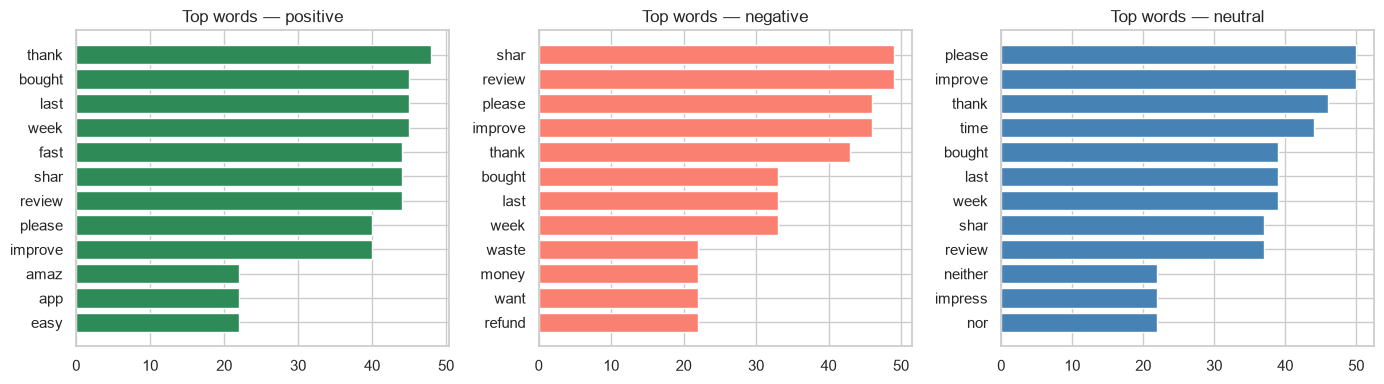

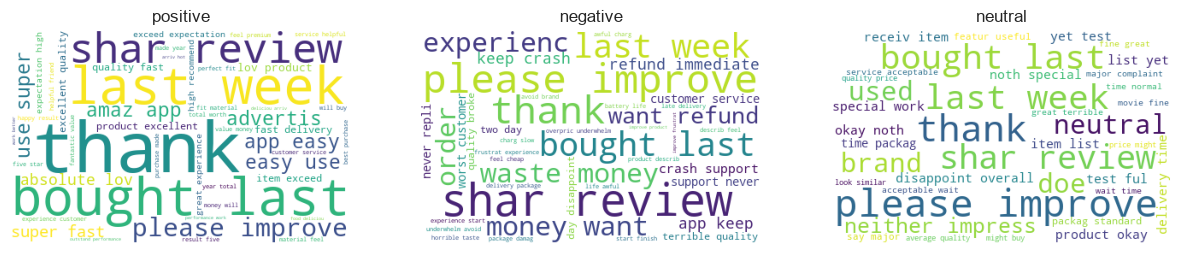

In [6]:
from collections import Counter

def top_words(label, n=12):
    text = " ".join(df.loc[df["sentiment"] == label, "clean_text"])
    return Counter(text.split()).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, label, color in zip(axes, ["positive", "negative", "neutral"], ["seagreen", "salmon", "steelblue"]):
    words, counts = zip(*top_words(label))
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
    ax.set_title(f"Top words — {label}")
plt.tight_layout()
plt.show()

try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, label in zip(axes, ["positive", "negative", "neutral"]):
        wc = WordCloud(width=400, height=250, background_color="white").generate(
            " ".join(df.loc[df["sentiment"] == label, "clean_text"])
        )
        ax.imshow(wc)
        ax.axis("off")
        ax.set_title(label)
    plt.show()
except Exception as e:
    print("WordCloud skipped:", e)


## 8. Error analysis

In [7]:
best_name = "Logistic Regression" if lr_m["f1"] >= nb_m["f1"] else "Naive Bayes"
best_pred = lr_pred if lr_m["f1"] >= nb_m["f1"] else nb_pred
err = pd.DataFrame({
    "review_text": X_test.values,
    "true": y_test.values,
    "predicted": best_pred,
})
miss = err[err["true"] != err["predicted"]].head(5)
# map back to original wording where possible
orig = df.set_index("clean_text")["review_text"]
rows = []
for _, r in miss.iterrows():
    original = orig.loc[r["review_text"]]
    if isinstance(original, pd.Series):
        original = original.iloc[0]
    rows.append({"review": original, "true": r["true"], "predicted": r["predicted"]})
pd.DataFrame(rows)


""


**Why misclassifications happen:** Neutral reviews often share words with both positive and negative (“okay”, “fine”, “average”). Short text has few tokens after stopword removal, so TF-IDF has little signal. Sarcasm and mixed sentiment (“good product but late delivery”) confuse bag-of-words models that ignore order.

## 9. Conclusion

Compare the metrics table: the model with the higher weighted F1 is preferred for imbalanced or mixed-difficulty classes.

**Real-world uses:** product review dashboards, support ticket triage, social listening, and flagging negative feedback for same-day response. For production, add more labelled data and consider handling mixed-aspect reviews (quality vs delivery) as separate tags.